<a href="https://colab.research.google.com/github/mfonabasi-01/online-payment-fraud-detection/blob/main/notebooks/Online_Payment_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Payment Fraud Detection Using Machine Learning

## Project Overview

This project analyzes a large online payment transaction dataset to identify patterns associated with fraudulent activity.

The project applies data preprocessing, exploratory data analysis, feature engineering, machine learning, and anomaly detection to investigate fraudulent transaction behavior and evaluate fraud detection methods.

## Key Questions

1. How common is fraud in the dataset?
2. Which transaction types have the highest fraud rates?
3. Are fraudulent transactions associated with unusual transaction amounts or balance changes?
4. How effective is the existing fraud-flagging mechanism?
5. Which features are most useful for detecting fraud?
6. Which machine-learning model performs best for fraud detection?
7. Can anomaly-detection techniques identify suspicious transactions beyond known fraud labels?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load original dataset
df = pd.read_csv(
    '/content/drive/MyDrive/new_data (1).csv'
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 6,362,620 rows × 11 columns


## 1. Data Quality Assessment

Before performing exploratory analysis or building machine-learning models, the dataset was assessed for data types, missing values, duplicate records, and overall data quality.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
missing_values = df.isnull().sum()

missing_values

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Data Quality Findings

The dataset contains 6,362,620 transaction records and 11 features. An initial data quality assessment found no missing values and no duplicate records.

The dataset therefore did not require missing-value imputation or duplicate removal before exploratory analysis.

The dataset contains numerical transaction and account-balance features, categorical transaction and account identifiers, and two fraud-related indicators: `isFraud` and `isFlaggedFraud`.

## 2. Exploratory Data Analysis

### 2.1 Fraud Class Distribution

The first stage of exploratory analysis examines the distribution of legitimate and fraudulent transactions. Understanding class distribution is particularly important for fraud detection because highly imbalanced datasets can make accuracy alone a misleading measure of model performance.

In [ ]:
fraud_counts = df['isFraud'].value_counts()
fraud_percentages = df['isFraud'].value_counts(normalize=True) * 100

print("Transaction Counts:")
print(fraud_counts)

print("\nTransaction Percentages:")
print(fraud_percentages)

Transaction Counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Transaction Percentages:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


### Finding

The dataset is highly imbalanced. Of 6,362,620 transactions, 6,354,407 (99.87%) are legitimate, while only 8,213 (0.13%) are fraudulent.

This imbalance is important when evaluating fraud-detection models. Accuracy alone may be misleading because a model that predicts most transactions as legitimate could achieve high accuracy while failing to detect fraudulent activity. Therefore, metrics such as precision, recall, F1-score, and ROC-AUC will be considered during model evaluation.

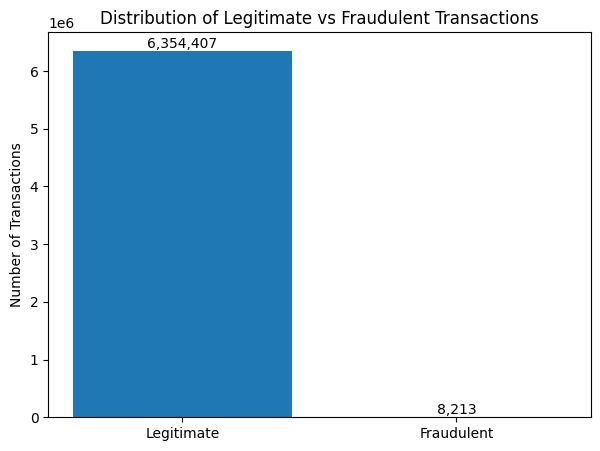

In [ ]:
fraud_labels = ['Legitimate', 'Fraudulent']
fraud_values = [
    (df['isFraud'] == 0).sum(),
    (df['isFraud'] == 1).sum()
]

plt.figure(figsize=(7, 5))
bars = plt.bar(fraud_labels, fraud_values)

plt.title('Distribution of Legitimate vs Fraudulent Transactions')
plt.ylabel('Number of Transactions')

for bar, value in zip(bars, fraud_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.show()

### 2.2 Fraud Analysis by Transaction Type

Transaction type was examined to determine whether fraudulent activity is distributed across all payment categories or concentrated within specific types of transactions.

In [ ]:
fraud_by_type = (
    df.groupby('type')['isFraud']
      .agg(['count', 'sum', 'mean'])
      .sort_values('mean', ascending=False)
)

fraud_by_type.columns = [
    'Total Transactions',
    'Fraudulent Transactions',
    'Fraud Rate'
]

fraud_by_type['Fraud Rate (%)'] = fraud_by_type['Fraud Rate'] * 100

fraud_by_type

,Total Transactions,Fraudulent Transactions,Fraud Rate,Fraud Rate (%)
type,,,,
TRANSFER,532909,4097,0.007688,0.768799
CASH_OUT,2237500,4116,0.001840,0.183955
CASH_IN,1399284,0,0.000000,0.000000
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000


### Finding

Fraudulent activity is concentrated entirely within `TRANSFER` and `CASH_OUT` transactions. No fraudulent transactions were observed among `CASH_IN`, `DEBIT`, or `PAYMENT` transactions.

Although `CASH_OUT` contains slightly more fraud cases (4,116) than `TRANSFER` (4,097), `TRANSFER` has the highest fraud rate at approximately 0.77%, compared with approximately 0.18% for `CASH_OUT`.

This demonstrates why fraud rates should be considered alongside raw fraud counts. Transaction volume alone does not indicate the relative risk associated with a transaction type.

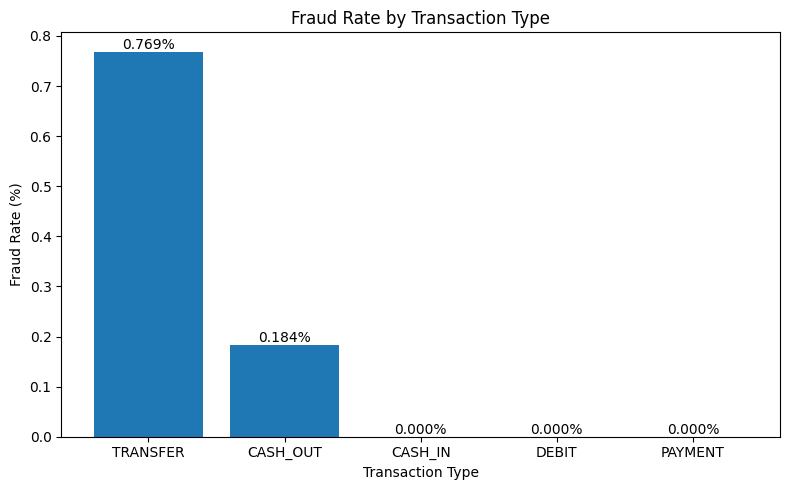

In [ ]:
fraud_rate_plot = (
    fraud_by_type['Fraud Rate (%)']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    fraud_rate_plot.index,
    fraud_rate_plot.values
)

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

for bar, value in zip(bars, fraud_rate_plot.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:.3f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### 2.3 Transaction Amount Analysis

Transaction amounts were compared between legitimate and fraudulent transactions to determine whether fraudulent activity exhibits different monetary patterns.

In [ ]:
amount_analysis = df.groupby('isFraud')['amount'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max'
])

amount_analysis.index = ['Legitimate', 'Fraudulent']

amount_analysis

,count,mean,median,min,max
Legitimate,6354407,1.781970e+05,74684.72,0.01,92445516.64
Fraudulent,8213,1.467967e+06,441423.44,0.00,10000000.00


### Finding

Fraudulent transactions tend to involve substantially larger amounts than legitimate transactions.

The median fraudulent transaction is approximately $441,423, compared with approximately $74,685 for legitimate transactions. The mean amount also differs substantially, at approximately $1.47 million for fraudulent transactions compared with $178,197 for legitimate transactions.

The difference between the mean and median, along with the presence of very large maximum transaction values, indicates that the amount distribution is skewed by high-value transactions. For this reason, both median and mean were considered when comparing the two groups.

These results suggest that transaction amount may be an informative feature for fraud detection.

In [ ]:
legit_median = df.loc[df['isFraud'] == 0, 'amount'].median()
fraud_median = df.loc[df['isFraud'] == 1, 'amount'].median()

median_ratio = fraud_median / legit_median

print(f"Median legitimate transaction: ${legit_median:,.2f}")
print(f"Median fraudulent transaction: ${fraud_median:,.2f}")
print(f"Median fraudulent transactions are {median_ratio:.2f}x larger.")

Median legitimate transaction: $74,684.72
Median fraudulent transaction: $441,423.44
Median fraudulent transactions are 5.91x larger.


### Transaction Amount Distribution

Because transaction amounts are highly skewed and contain extreme values, a logarithmic scale was used to improve visualization of the amount distributions for legitimate and fraudulent transactions.

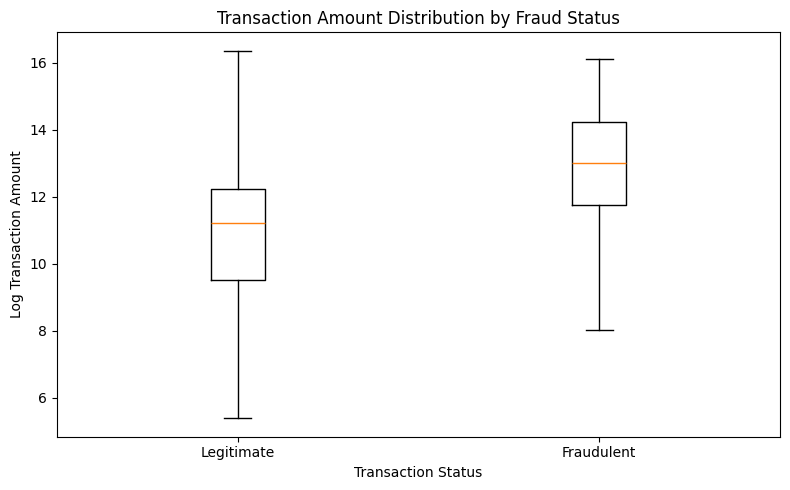

In [ ]:
plot_data = df[['amount', 'isFraud']].copy()

# log1p safely handles transactions with an amount of 0
plot_data['log_amount'] = np.log1p(plot_data['amount'])

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        plot_data.loc[plot_data['isFraud'] == 0, 'log_amount'],
        plot_data.loc[plot_data['isFraud'] == 1, 'log_amount']
    ],
    tick_labels=['Legitimate', 'Fraudulent'],
    showfliers=False
)

plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Status')
plt.ylabel('Log Transaction Amount')
plt.tight_layout()
plt.show()

### 2.4 Existing Fraud-Flagging Analysis

The dataset contains both an actual fraud indicator (`isFraud`) and an existing fraud-flag indicator (`isFlaggedFraud`). These variables were compared to evaluate how frequently the existing flagging mechanism identifies transactions labeled as fraudulent.

In [ ]:
flag_comparison = pd.crosstab(
    df['isFraud'],
    df['isFlaggedFraud'],
    rownames=['Actual Fraud'],
    colnames=['Flagged as Fraud']
)

flag_comparison

Flagged as Fraud,0,1
Actual Fraud,,
0,6354407,0
1,8197,16


In [ ]:
actual_fraud = (df['isFraud'] == 1).sum()

flagged_fraud = (
    (df['isFraud'] == 1) &
    (df['isFlaggedFraud'] == 1)
).sum()

missed_fraud = actual_fraud - flagged_fraud

detection_rate = (flagged_fraud / actual_fraud) * 100
miss_rate = (missed_fraud / actual_fraud) * 100

print(f"Actual fraudulent transactions: {actual_fraud:,}")
print(f"Fraudulent transactions flagged: {flagged_fraud:,}")
print(f"Fraudulent transactions not flagged: {missed_fraud:,}")
print(f"Flagging rate among fraud: {detection_rate:.3f}%")
print(f"Unflagged rate among fraud: {miss_rate:.3f}%")

Actual fraudulent transactions: 8,213
Fraudulent transactions flagged: 16
Fraudulent transactions not flagged: 8,197
Flagging rate among fraud: 0.195%
Unflagged rate among fraud: 99.805%


### Finding

Of the 8,213 transactions labeled as fraudulent, only 16 were also marked by `isFlaggedFraud`, while 8,197 fraudulent transactions were not flagged.

This corresponds to a flagging rate of approximately 0.19% among transactions labeled as fraud.

At the same time, none of the legitimate transactions were marked by `isFlaggedFraud`. This indicates that the existing flag is highly selective but captures only a very small subset of the transactions identified as fraudulent in the dataset.

Because the dataset does not establish that `isFlaggedFraud` was intended to function as a comprehensive fraud-detection system, this analysis should not be interpreted as a complete evaluation of an existing detection model. Instead, it demonstrates that the fraud label contains substantially more fraudulent activity than is represented by the flagging indicator.

## 3. Feature Engineering

New features were derived from account balances and transaction amounts to capture transaction behavior that may not be immediately apparent from the original variables.

In particular, balance-change and balance-discrepancy features were created to investigate whether fraudulent transactions exhibit unusual relationships between the transaction amount and the recorded changes in sender or recipient balances.

In [ ]:
# Sender's observed balance decrease
df['orig_balance_change'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

# Recipient's observed balance increase
df['dest_balance_change'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)

# Difference between transaction amount and observed sender balance movement
df['orig_balance_error'] = abs(
    df['amount'] - df['orig_balance_change']
)

# Difference between transaction amount and observed recipient balance movement
df['dest_balance_error'] = abs(
    df['amount'] - df['dest_balance_change']
)

df[
    [
        'amount',
        'orig_balance_change',
        'dest_balance_change',
        'orig_balance_error',
        'dest_balance_error',
        'isFraud'
    ]
].head()

,amount,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error,isFraud
0,9839.64,9839.64,0.0,1.455192e-11,9839.64,0
1,1864.28,1864.28,0.0,1.136868e-12,1864.28,0
2,181.00,181.00,0.0,0.000000e+00,181.00,1
3,181.00,181.00,-21182.0,0.000000e+00,21363.00,1
4,11668.14,11668.14,0.0,0.000000e+00,11668.14,0


In [ ]:
balance_analysis = df.groupby('isFraud')[
    [
        'orig_balance_error',
        'dest_balance_error'
    ]
].median()

balance_analysis.index = ['Legitimate', 'Fraudulent']

balance_analysis

,orig_balance_error,dest_balance_error
Legitimate,69049.31,5123.10
Fraudulent,0.00,9511.69


### Balance Discrepancy Analysis

The engineered sender balance discrepancy showed a notable difference between fraudulent and legitimate transactions. The median sender balance error was $0 for fraudulent transactions compared with approximately $69,049 for legitimate transactions.

To determine whether a zero balance discrepancy is specifically associated with fraud, the frequency of zero sender-balance errors was examined within each class.

In [ ]:
zero_error_analysis = (
    df.assign(zero_orig_error=df['orig_balance_error'] == 0)
      .groupby('isFraud')['zero_orig_error']
      .agg(['count', 'sum', 'mean'])
)

zero_error_analysis.index = ['Legitimate', 'Fraudulent']

zero_error_analysis.columns = [
    'Total Transactions',
    'Zero Balance Error',
    'Proportion'
]

zero_error_analysis['Percentage (%)'] = (
    zero_error_analysis['Proportion'] * 100
)

zero_error_analysis

,Total Transactions,Zero Balance Error,Proportion,Percentage (%)
Legitimate,6354407,432367,0.068042,6.804207
Fraudulent,8213,8144,0.991599,99.159869


### Balance Discrepancy Analysis

The engineered sender balance discrepancy showed a notable difference between fraudulent and legitimate transactions. The median sender balance error was $0 for fraudulent transactions compared with approximately $69,049 for legitimate transactions.

To determine whether a zero balance discrepancy is specifically associated with fraud, the frequency of zero sender-balance errors was examined within each class.

In [ ]:
zero_error_analysis = (
    df.assign(zero_orig_error=df['orig_balance_error'] == 0)
      .groupby('isFraud')['zero_orig_error']
      .agg(['count', 'sum', 'mean'])
)

zero_error_analysis.index = ['Legitimate', 'Fraudulent']

zero_error_analysis.columns = [
    'Total Transactions',
    'Zero Balance Error',
    'Proportion'
]

zero_error_analysis['Percentage (%)'] = (
    zero_error_analysis['Proportion'] * 100
)

zero_error_analysis

,Total Transactions,Zero Balance Error,Proportion,Percentage (%)
Legitimate,6354407,432367,0.068042,6.804207
Fraudulent,8213,8144,0.991599,99.159869


In [ ]:
engineered_summary = df.groupby('isFraud')[
    [
        'orig_balance_change',
        'dest_balance_change',
        'orig_balance_error',
        'dest_balance_error'
    ]
].median()

engineered_summary.index = ['Legitimate', 'Fraudulent']

engineered_summary

,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error
Legitimate,0.00,0.0,69049.31,5123.10
Fraudulent,436317.49,0.0,0.00,9511.69


## 4. Machine Learning Preparation

The next stage evaluates whether transaction characteristics can be used to distinguish fraudulent from legitimate transactions.

The target variable is `isFraud`, where:

- `0` represents a legitimate transaction.
- `1` represents a fraudulent transaction.

Account identifiers were excluded because they primarily identify individual accounts rather than directly representing transaction behavior. The existing `isFlaggedFraud` field was also excluded from the predictor set to avoid relying on an existing fraud-related indicator when evaluating the new models.

In [ ]:
model_df = df[
    [
        'step',
        'type',
        'amount',
        'oldbalanceOrg',
        'newbalanceOrig',
        'oldbalanceDest',
        'newbalanceDest',
        'orig_balance_change',
        'dest_balance_change',
        'orig_balance_error',
        'dest_balance_error',
        'isFraud'
    ]
].copy()

model_df = pd.get_dummies(
    model_df,
    columns=['type'],
    drop_first=True
)

model_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0,1.455192e-11,9839.64,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0,1.136868e-12,1864.28,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,181.00,0.0,0.000000e+00,181.00,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0,0.000000e+00,21363.00,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0,0.000000e+00,11668.14,0,False,False,True,False


In [ ]:
X = model_df.drop('isFraud', axis=1)
y = model_df['isFraud']

print("Feature matrix:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix: (6362620, 14)
Target: (6362620,)

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


### Train-Test Split

The dataset was divided into training and testing subsets using stratified sampling. Stratification preserves the highly imbalanced fraud distribution in both subsets, ensuring that fraudulent transactions are appropriately represented during training and evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")

print("\nTraining fraud distribution:")
print(y_train.value_counts())

print("\nTesting fraud distribution:")
print(y_test.value_counts())

Training records: 4,453,834
Testing records: 1,908,786

Training fraud distribution:
isFraud
0    4448085
1       5749
Name: count, dtype: int64

Testing fraud distribution:
isFraud
0    1906322
1       2464
Name: count, dtype: int64


### Feature Scaling

Numerical features were standardized using `StandardScaler`. The scaler was fitted only on the training data and subsequently applied to the testing data to prevent data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


### Baseline Model

Because approximately 99.87% of transactions are legitimate, overall accuracy can be misleading. A naive model that predicts every transaction as legitimate would achieve very high accuracy while detecting no fraud.

A baseline classifier was therefore evaluated before training the machine-learning models.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print(classification_report(
    y_test,
    baseline_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.00      0.00      0.00      2464

    accuracy                           1.00   1908786
   macro avg       0.50      0.50      0.50   1908786
weighted avg       1.00      1.00      1.00   1908786



## 5. Model Training and Evaluation

Three classification algorithms were initially evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models represent different approaches to binary classification and were compared using metrics appropriate for highly imbalanced fraud data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.999208,0.894693,0.437906,0.588011,0.983461
1,Decision Tree,0.999986,0.993522,0.995942,0.994730,0.997967
2,Random Forest,0.999995,1.000000,0.996347,0.998170,0.998171


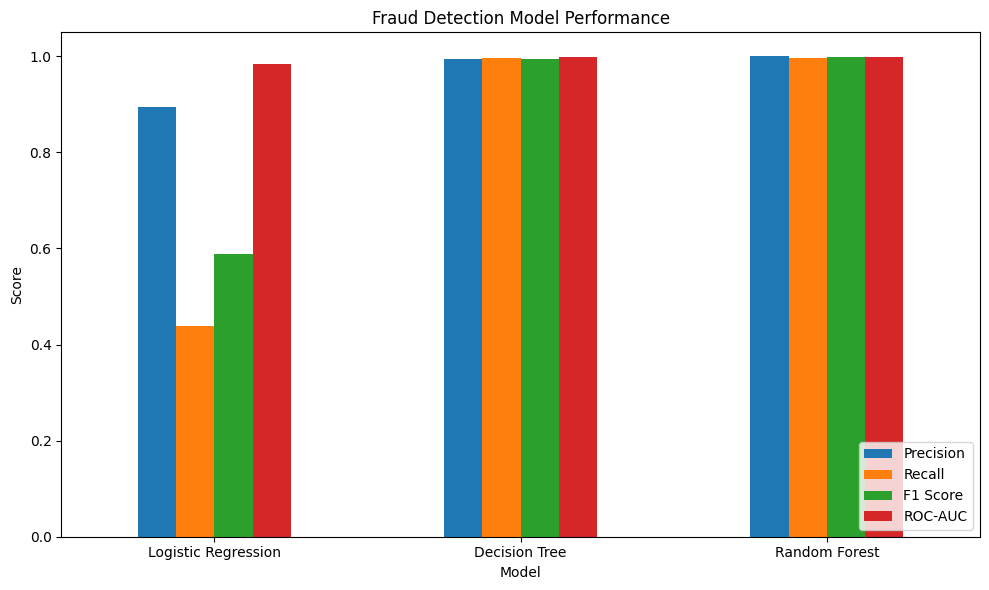

In [ ]:
comparison_plot = results_df.set_index('Model')[
    ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
]

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Fraud Detection Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Best Model Evaluation

Random Forest achieved the strongest overall performance among the evaluated models. Because overall accuracy can be misleading in highly imbalanced fraud datasets, its predictions were examined further using a confusion matrix to quantify correctly detected fraud, missed fraud, and false-positive alerts.

Confusion Matrix:
[[1906322       0]
 [      9    2455]]


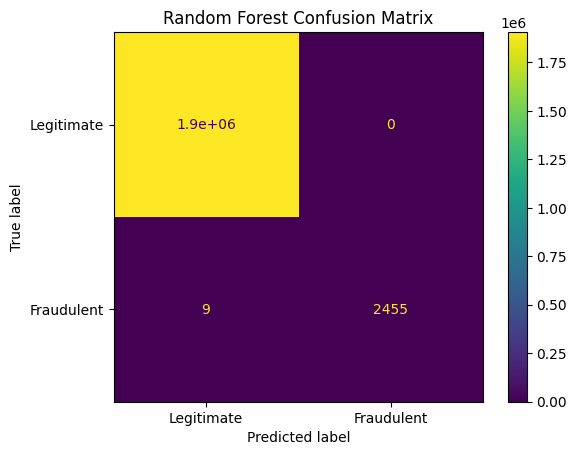

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = trained_models['Random Forest']

y_pred_rf = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Fraudulent']
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

### Feature Importance Analysis

To better understand the Random Forest model's predictions, feature importance was examined. This helps identify which transaction characteristics contributed most strongly to the model's fraud classifications and provides an additional check for potentially dominant or problematic features.

In [ ]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
newbalanceOrig,0.316799
orig_balance_change,0.203974
orig_balance_error,0.122075
newbalanceDest,0.072590
dest_balance_change,0.058416
amount,0.055792
oldbalanceOrg,0.040074
step,0.039671
dest_balance_error,0.029536
type_TRANSFER,0.026801


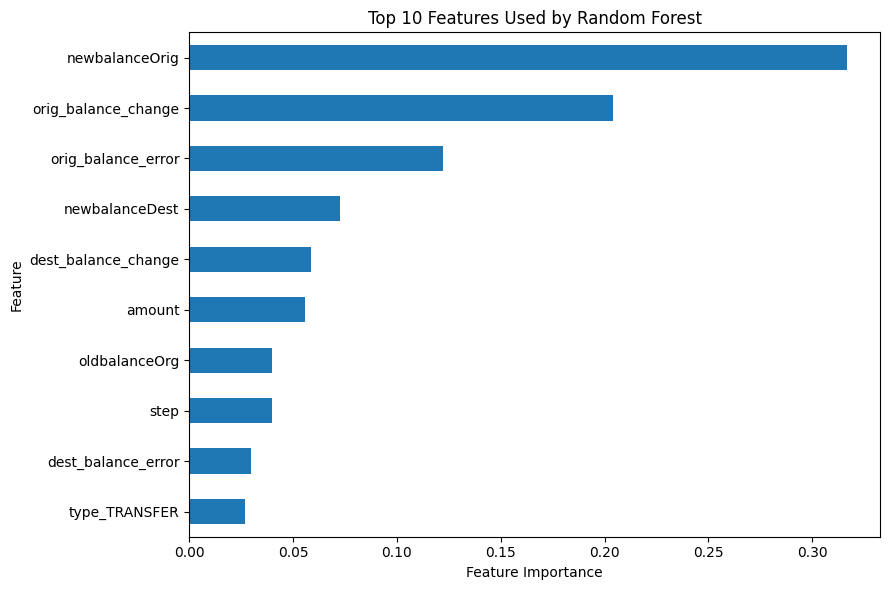

In [ ]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind='barh')

plt.title('Top 10 Features Used by Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Robustness Check

Because engineered balance features contributed substantially to the Random Forest model, a secondary model was trained using only the original transaction features.

This sensitivity analysis evaluates whether the strong classification performance depends heavily on engineered features and provides an additional check against overly optimistic model performance.

In [ ]:
original_features = [
    'step',
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

X_original = df[original_features].copy()

X_original = pd.get_dummies(
    X_original,
    columns=['type'],
    drop_first=True
)

y_original = df['isFraud']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original,
    y_original,
    test_size=0.30,
    random_state=42,
    stratify=y_original
)

In [ ]:
rf_original = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_original.fit(X_train_orig, y_train_orig)

y_pred_orig = rf_original.predict(X_test_orig)
y_prob_orig = rf_original.predict_proba(X_test_orig)[:, 1]

original_results = {
    'Accuracy': accuracy_score(y_test_orig, y_pred_orig),
    'Precision': precision_score(y_test_orig, y_pred_orig),
    'Recall': recall_score(y_test_orig, y_pred_orig),
    'F1 Score': f1_score(y_test_orig, y_pred_orig),
    'ROC-AUC': roc_auc_score(y_test_orig, y_prob_orig)
}

pd.Series(original_results)

,0
Accuracy,0.999692
Precision,0.979060
Recall,0.778003
F1 Score,0.867028
ROC-AUC,0.995982


### Robustness Check Finding

The Random Forest model trained using only the original transaction features achieved 97.91% precision, 77.80% recall, an F1-score of 86.70%, and a ROC-AUC of 99.60%.

After incorporating the engineered balance-change and balance-discrepancy features, recall increased from 77.80% to 99.63%, while precision increased from 97.91% to 100%. The F1-score increased from 86.70% to 99.82%.

This sensitivity analysis indicates that the engineered balance features contributed substantial predictive information, particularly by improving the model's ability to identify fraudulent transactions.

The results also demonstrate why accuracy alone is insufficient for evaluating fraud-detection models: the original-feature model achieved 99.97% accuracy despite missing more than one-fifth of fraudulent transactions.

In [47]:
!pip install pyod -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 7.0 MB/s eta 0:00:00


## 6. Anomaly Detection

An unsupervised anomaly-detection approach was explored to identify transactions exhibiting unusual behavior without using the `isFraud` label during model fitting.

Because distance-based anomaly detection can be computationally expensive on the full dataset of more than 6.3 million transactions, a sample was used for this analysis.

In [48]:
fraud_sample = df[df['isFraud'] == 1].sample(
    n=2000,
    random_state=42
)

legit_sample = df[df['isFraud'] == 0].sample(
    n=48000,
    random_state=42
)

anomaly_df = pd.concat(
    [fraud_sample, legit_sample]
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(f"Sample size: {len(anomaly_df):,}")
print(anomaly_df['isFraud'].value_counts())

Sample size: 50,000
isFraud
0    48000
1     2000
Name: count, dtype: int64


In [49]:
anomaly_features = anomaly_df[
    [
        'amount',
        'oldbalanceOrg',
        'newbalanceOrig',
        'oldbalanceDest',
        'newbalanceDest',
        'orig_balance_error',
        'dest_balance_error'
    ]
]

anomaly_scaler = StandardScaler()
X_anomaly = anomaly_scaler.fit_transform(anomaly_features)

print("Features prepared:", X_anomaly.shape)

Features prepared: (50000, 7)


In [50]:
from pyod.models.knn import KNN

detector = KNN(
    n_neighbors=5,
    contamination=0.04
)

detector.fit(X_anomaly)

anomaly_df['anomaly'] = detector.labels_

print(anomaly_df['anomaly'].value_counts())

anomaly
0    48000
1     2000
Name: count, dtype: int64


In [51]:
anomaly_results = pd.crosstab(
    anomaly_df['isFraud'],
    anomaly_df['anomaly'],
    rownames=['Known Fraud'],
    colnames=['Detected as Anomaly']
)

anomaly_results

Detected as Anomaly,0,1
Known Fraud,,
0,46183,1817
1,1817,183


### Anomaly Detection Finding

The KNN anomaly detector identified 2,000 transactions as anomalous within the 50,000-transaction evaluation sample. Of the 2,000 known fraudulent transactions, 183 (9.15%) were identified as anomalies, while 1,817 were classified as normal.

The detector also identified 1,817 legitimate transactions as anomalous. This demonstrates that unusual transaction behavior does not necessarily correspond directly to known fraud: legitimate transactions may exhibit unusual characteristics, while fraudulent transactions may resemble normal transaction patterns.

Compared with the supervised classification models, anomaly detection was substantially less effective at identifying the known fraud cases in this experiment. However, unsupervised anomaly detection may still be useful for surfacing unusual transactions for further investigation when labeled fraud data is unavailable.

The anomaly-detection sample was deliberately constructed to contain 4% known fraud for evaluation purposes. Therefore, the results should not be interpreted as representing the fraud prevalence of the complete dataset.

## 7. Final Findings

This project analyzed more than 6.3 million online payment transactions to investigate fraudulent transaction patterns and evaluate data-driven approaches to fraud detection.

### Key Findings

- Fraud was extremely rare, representing approximately 0.13% of all transactions. This demonstrated why accuracy alone is an inappropriate measure of fraud-detection performance.

- Fraudulent activity occurred exclusively within `TRANSFER` and `CASH_OUT` transactions in this dataset. `TRANSFER` transactions had the highest fraud rate at approximately 0.77%.

- Fraudulent transactions generally involved larger amounts. The median fraudulent transaction was approximately $441,423 compared with approximately $74,685 for legitimate transactions.

- Only 16 of the 8,213 transactions labeled as fraudulent were also marked by `isFlaggedFraud`, demonstrating that the two fraud-related indicators represent substantially different subsets of activity.

- Balance-based feature engineering revealed meaningful differences between legitimate and fraudulent transaction behavior.

- Among Logistic Regression, Decision Tree, and Random Forest, Random Forest achieved the strongest classification performance.

- The engineered-feature Random Forest achieved 100% precision and approximately 99.63% recall on the held-out test set, detecting 2,455 of 2,464 fraudulent transactions with no false-positive classifications.

- A robustness comparison showed the importance of feature engineering. Random Forest recall increased from approximately 77.80% using the original transaction features to 99.63% after incorporating engineered balance-change and balance-discrepancy features.

- Feature-importance analysis showed that sender balance behavior, particularly `newbalanceOrig`, `orig_balance_change`, and `orig_balance_error`, contributed substantially to the model's predictions.

- KNN-based anomaly detection identified 9.15% of the known fraudulent transactions as anomalous within the evaluation sample. This demonstrated that anomalous behavior and known fraud are not necessarily equivalent and that supervised classification was substantially more effective for this labeled dataset.

## 8. Limitations

- The analysis was performed on a simulated online payment dataset, so model performance should not be interpreted as expected performance in a real financial institution.

- The dataset is highly imbalanced, with fraudulent transactions representing only approximately 0.13% of the complete dataset.

- The strong Random Forest performance is partly associated with balance-derived features that contain substantial predictive information in this dataset. Performance on real-world transaction data may differ considerably.

- The models were evaluated using a single stratified train-test split. Additional validation techniques would be required before considering a model for production use.

- The anomaly-detection experiment used a deliberately constructed 50,000-transaction sample containing 4% known fraud to enable evaluation. This does not represent the fraud prevalence of the complete dataset.

- Unsupervised anomaly detection identifies unusual behavior rather than fraud specifically; therefore, anomalous transactions would require further investigation.

- This project is an analytical demonstration and is not intended to represent a production fraud-detection system.

## 9. Conclusion

The project demonstrates how exploratory data analysis, feature engineering, supervised machine learning, and anomaly detection can be combined to investigate fraud within large-scale transaction data.

The analysis also highlights the importance of selecting evaluation metrics appropriate for highly imbalanced security problems. Although a baseline classifier achieved approximately 99.87% accuracy by predicting transactions as legitimate, it detected no fraud. Precision, recall, F1-score, ROC-AUC, and confusion-matrix analysis therefore provided a more meaningful assessment of model performance.

Feature engineering produced the largest improvement in supervised fraud detection, particularly in recall, demonstrating the value of transforming raw transaction data into behavioral indicators that better represent suspicious activity.